In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import warnings

In [4]:
df_train_init = pd.read_csv("train.csv", sep=';', parse_dates=['date'], index_col='date')
df_test_init = pd.read_csv("test.csv", sep=';', parse_dates=['date'], index_col='date')
df_train_monthly = df_train_init.interpolate(method='time').resample('ME').mean()
df_test_monthly = df_test_init.interpolate(method='time').resample('ME').mean()

In [5]:
prophet_df = df_train_monthly.reset_index().rename(columns={'date': 'ds', 'target': 'y'})
prophet_test = df_test_monthly.reset_index().rename(columns={'date': 'ds', 'target': 'y'})
nb_valid = 48 
train_df = prophet_df[:-nb_valid].copy()
valid_df = prophet_df[-nb_valid:].copy()
print("Train shape :", train_df.shape)
print("Valid shape :", valid_df.shape)

Train shape : (240, 2)
Valid shape : (48, 2)


In [6]:
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=False, 
    daily_seasonality=False
)
model.fit(train_df)

15:20:40 - cmdstanpy - INFO - Chain [1] start processing
15:20:41 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(periods=nb_valid, freq='ME')
forecast = model.predict(future)
valid_preds = forecast.iloc[-nb_valid:]['yhat']
mse = mean_squared_error(valid_df['y'], valid_preds)
print(f"MSE sur la validation : {mse:.4f}")

MSE sur la validation : 16.3149


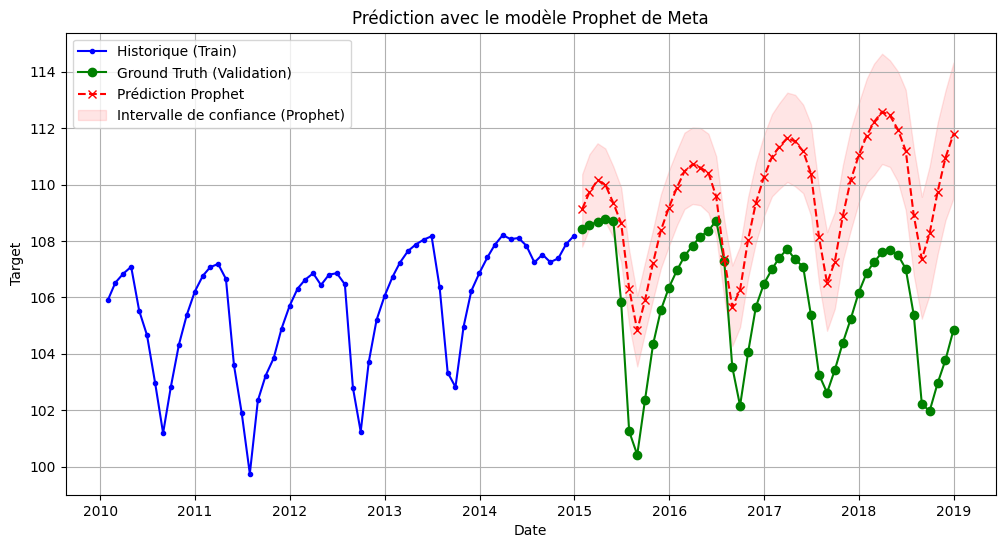

In [8]:
plt.figure(figsize=(12, 6))
hist_len = 60
hist_df = train_df.iloc[-hist_len:]
plt.plot(hist_df['ds'], hist_df['y'], label='Historique (Train)', color='blue', marker='.')
plt.plot(valid_df['ds'], valid_df['y'], label='Ground Truth (Validation)', color='green', marker='o')
valid_forecast = forecast.iloc[-nb_valid:]
plt.plot(valid_forecast['ds'], valid_forecast['yhat'], label='Prédiction Prophet', color='red', linestyle='--', marker='x')
plt.fill_between(
    valid_forecast['ds'], 
    valid_forecast['yhat_lower'], 
    valid_forecast['yhat_upper'], 
    color='red', alpha=0.1, label='Intervalle de confiance (Prophet)'
)
plt.title('Prédiction avec le modèle Prophet de Meta')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

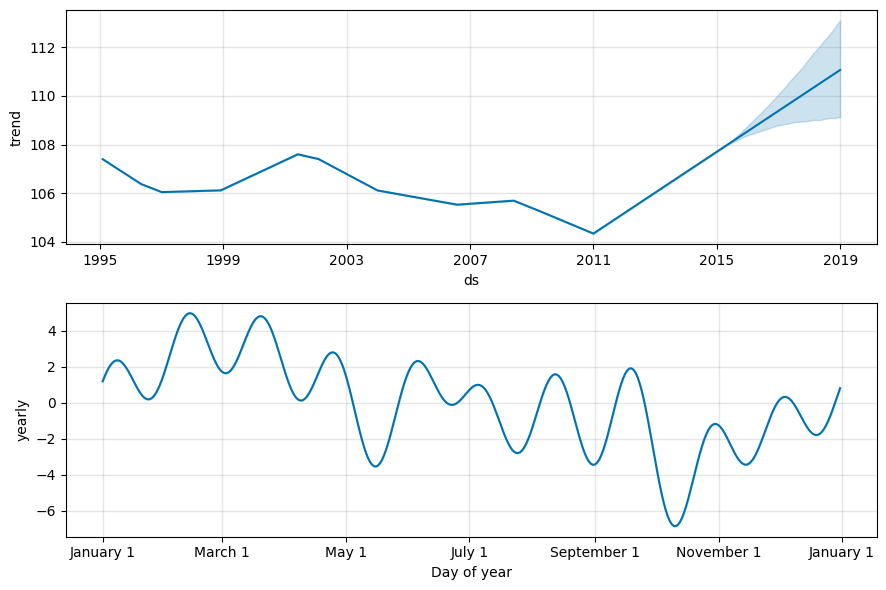

In [9]:
fig2 = model.plot_components(forecast)